# 03 - LSTM Model Training

Train a TensorFlow/Keras LSTM for next-day demand forecasting.

The model is intentionally small enough to understand and explain during an interview.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.random.set_seed(42)
np.random.seed(42)

train = pd.read_csv("../data/train.csv", parse_dates=["date"])

STORE_ID = 1
ITEM_ID = 1
LOOKBACK = 30

series = (
    train[(train["store"] == STORE_ID) & (train["item"] == ITEM_ID)]
    .sort_values("date")
    [["date", "sales"]]
    .reset_index(drop=True)
)

values = series["sales"].values.astype("float32").reshape(-1, 1)

n = len(values)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

scaler = MinMaxScaler()
scaler.fit(values[:train_end])

scaled = scaler.transform(values)

def make_sequences(values, lookback=30):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i-lookback:i, 0])
        y.append(values[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(scaled[:train_end], LOOKBACK)
X_val, y_val = make_sequences(scaled[train_end-LOOKBACK:val_end], LOOKBACK)
X_test, y_test = make_sequences(scaled[val_end-LOOKBACK:], LOOKBACK)

X_train = X_train.reshape((-1, LOOKBACK, 1))
X_val = X_val.reshape((-1, LOOKBACK, 1))
X_test = X_test.reshape((-1, LOOKBACK, 1))

print(X_train.shape, X_val.shape, X_test.shape)

(1248, 30, 1) (274, 30, 1) (274, 30, 1)


In [2]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, 1)),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - loss: 0.0323 - mae: 0.1393 - val_loss: 0.0197 - val_mae: 0.1152
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0193 - mae: 0.1092 - val_loss: 0.0193 - val_mae: 0.1143
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0188 - mae: 0.1077 - val_loss: 0.0190 - val_mae: 0.1130
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0186 - mae: 0.1071 - val_loss: 0.0190 - val_mae: 0.1127
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0186 - mae: 0.1067 - val_loss: 0.0190 - val_mae: 0.1127
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0187 - mae: 0.1075 - val_loss: 0.0190 - val_mae: 0.1127
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0188 - mae: 0.1073 - val_loss: 0.0190 - val_mae: 0.1127
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0188 - mae: 0.1074 - val_loss: 0.0190 - val_mae: 0.1128
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.018

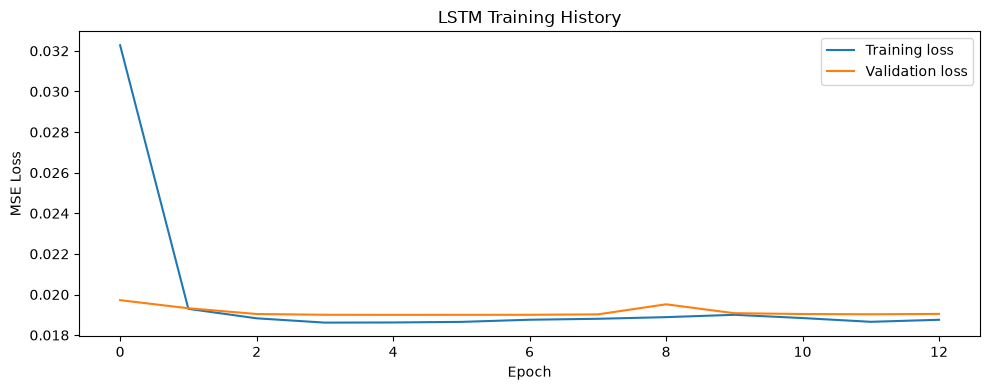

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled).flatten()
actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))

smape = np.mean(
    2 * np.abs(actual - pred) /
    (np.abs(actual) + np.abs(pred) + 1e-8)
) * 100

print(f"Test MAE: {mae:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test sMAPE: {smape:.2f}%")

Test MAE: 4.805
Test RMSE: 6.112
Test sMAPE: 20.86%


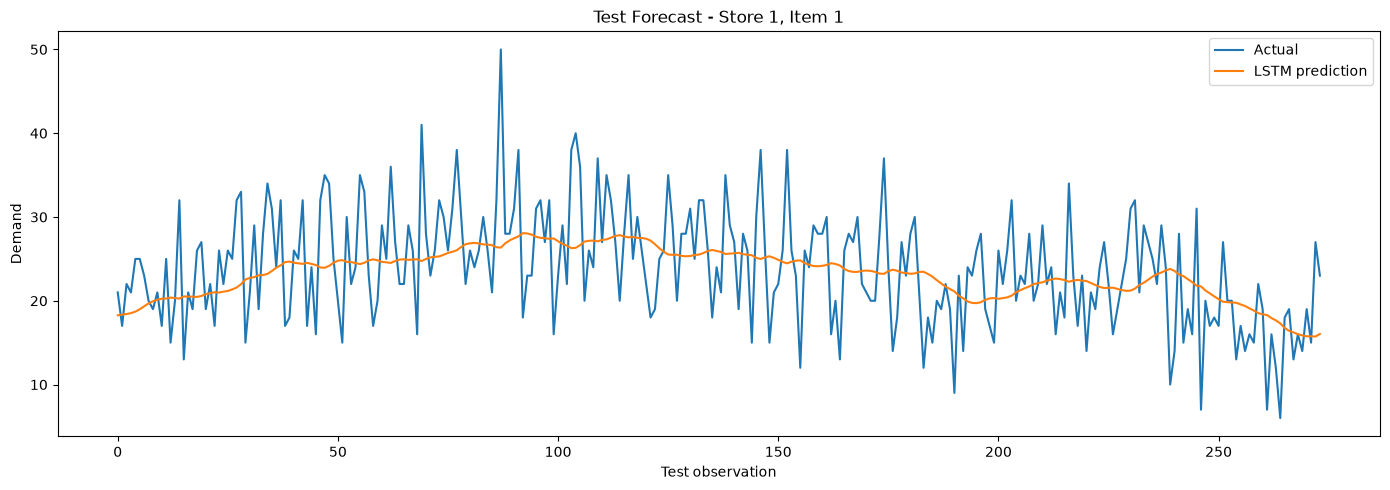

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(actual, label="Actual")
plt.plot(pred, label="LSTM prediction")
plt.title(f"Test Forecast - Store {STORE_ID}, Item {ITEM_ID}")
plt.xlabel("Test observation")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Save artifacts for optional local experimentation.
model.save("../models/demand_lstm.keras")

import joblib
joblib.dump(scaler, "../models/scaler.pkl")

print("Saved model and scaler to ../models/")

Saved model and scaler to ../models/


## Interview explanation

The LSTM receives a tensor shaped like:

```text
(samples, 30 time steps, 1 feature)
```

It learns relationships between recent demand observations and the next day's demand.

The model is not claimed to be universally optimal. A strong forecasting project should compare the LSTM with simple baselines and discuss where it performs well or poorly.